# ERA5 Pretrained — flash-aurora Engine

Same data and forecast as the upstream [Microsoft Aurora example](microsoft-aurora/docs/example_era5.ipynb) (2023-01-01, 2-step rollout to 12:00 and 18:00 UTC), using the flash-aurora `AuroraEngine` and `DataDownloader` for ERA5 ingress and inference.

## Prerequisites

CDS credentials are required for the first download (ERA5 files are cached locally afterwards). Provide them via the `CDSAPI_KEY` environment variable, a `~/.cdsapirc` file, or interactive input in the download cell. Dependencies are bundled with the project (`uv sync`). A CUDA-capable GPU is recommended for 0.25-degree global inference. If `huggingface.co` is unreachable, set `USE_HF_MIRROR = True` in the setup cell.


## Setup data downloader and engine

In [1]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "era5_pretrained"
VALID_TIME = datetime(2023, 1, 1, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"  # e.g. "tf32@tf32", "fp32", "bf16@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision=INFERENCE_PRECISION,
)

print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))


checkpoint: ~/autodl-tmp/aurora/aurora-0.25-pretrained.ckpt
cache_dir: ~/autodl-tmp/aurora/era5
asset_root: ~/autodl-tmp/aurora


## 1. Download ERA5 (CDS API)

Downloads three NetCDF files under `<ASSET_ROOT>/era5/`. Already-present files are skipped without touching your API quota.


In [ ]:
import getpass
import os

missing_files = downloader.missing(VALID_TIME)
cds_api_key = None

if missing_files:
    cds_api_key = os.environ.get("CDSAPI_KEY", "").strip() or None
    # cds_api_key = "paste-your-cds-key-here"
    if cds_api_key is None and not Path.home().joinpath(".cdsapirc").is_file():
        cds_api_key = getpass.getpass("CDS API key: ").strip() or None
    if not cds_api_key and not Path.home().joinpath(".cdsapirc").is_file():
        raise ValueError(
            "No CDS credentials found. Set CDSAPI_KEY, create ~/.cdsapirc, "
            "or paste your key when prompted."
        )
    # os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"
    print("Downloading missing ERA5 files:", missing_files)

result = downloader.ensure(VALID_TIME, cds_api_key=cds_api_key)
print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


downloaded: ()
skipped: ('static', 'surface', 'atmospheric')
  static: ~/autodl-tmp/aurora/era5/static.nc
  surface: ~/autodl-tmp/aurora/era5/2023-01-01-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/era5/2023-01-01-atmospheric.nc


## 2. Build the initial condition

`InitialConditionBuilder` reads the downloaded ERA5 NetCDF files and assembles a `Batch` with the two-timestep history required by Aurora. The resulting `batch` is reused for both the in-memory rollout in section 3 and the optional NetCDF export in section 5.


In [3]:
request = downloader.ingest_request(VALID_TIME, time_index=TIME_INDEX, download=False)
batch = InitialConditionBuilder(engine.config).from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)


IC time: (datetime.datetime(2023, 1, 1, 6, 0),)
spatial: torch.Size([721, 1440])


## 3. Load the model and rollout

`INFERENCE_PRECISION` is passed to `AuroraEngine.from_preset()` in the setup cell, so Triton fusion, CuTe window attention, and matmul precision are wired before the weights load. Predictions are moved to CPU immediately to keep GPU memory available for the export step.


In [4]:
import torch

from flash_aurora.aurora.model.inference_precision import describe_inference_config

engine.load(rollout_steps=ROLLOUT_STEPS)
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

with torch.inference_mode():
    preds = [pred.to("cpu") for pred in engine.rollout_stream(batch, ROLLOUT_STEPS)]

print("predictions:", [str(p.metadata.time[0]) for p in preds])


device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
predictions: ['2023-01-01 12:00:00', '2023-01-01 18:00:00']


## 4. Visualize: Aurora prediction vs ERA5 ground truth

Left column: model forecast. Right column: ERA5 2-metre temperature at the matching valid time (\(K \to ^{\circ}C\)).


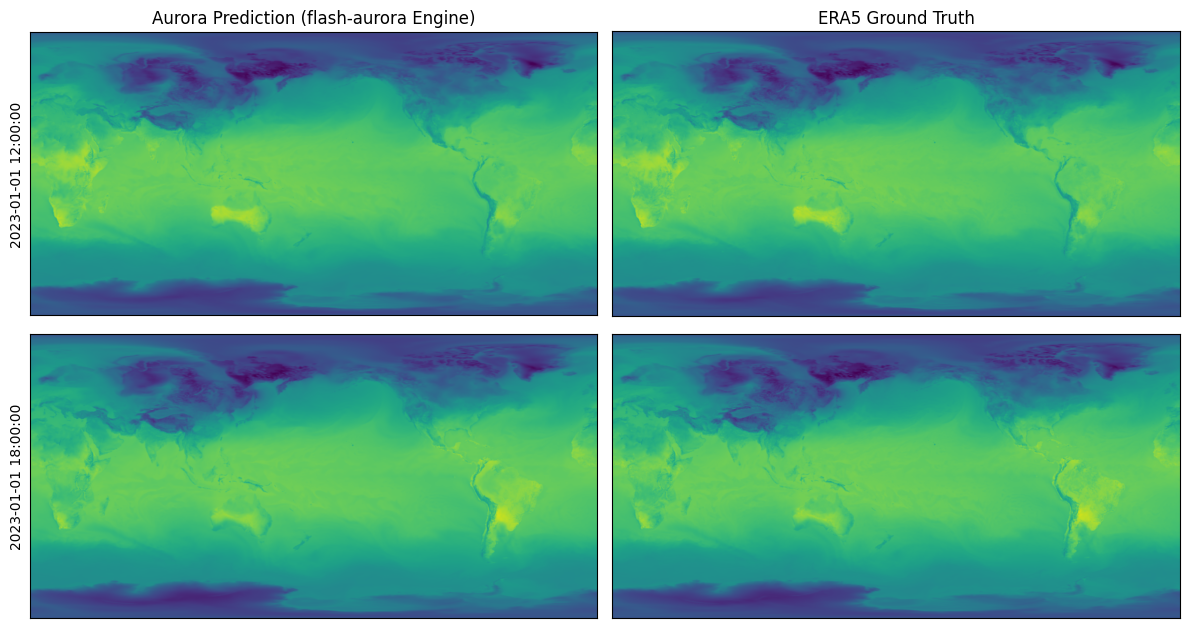

In [5]:
import matplotlib.pyplot as plt
import xarray as xr

# ERA5 surface file covers the full day in 6-hourly steps.
# Forecast valid times start one step after TIME_INDEX in that sequence.
ERA5_FORECAST_START_IDX = TIME_INDEX + 1

with xr.open_dataset(result.paths["surface"], engine="netcdf4") as surf_ds:
    fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))

    for i, (ax_row, pred) in enumerate(zip(axes, preds)):
        t2m_pred = pred.surf_vars["2t"][0, 0].numpy() - 273.15
        t2m_gt = surf_ds["t2m"][ERA5_FORECAST_START_IDX + i].values - 273.15

        ax_row[0].imshow(t2m_pred, vmin=-50, vmax=50)
        ax_row[0].set_ylabel(str(pred.metadata.time[0]))
        ax_row[1].imshow(t2m_gt, vmin=-50, vmax=50)

        if i == 0:
            ax_row[0].set_title("Aurora Prediction (flash-aurora Engine)")
            ax_row[1].set_title("ERA5 Ground Truth")

        for ax in ax_row:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


## 5. (Optional) Export rollout to NetCDF

`rollout_and_export` re-runs the same rollout from `batch` and writes one file per step under `EXPORT_DIR` (`prediction-000.nc`, `prediction-001.nc`, ...). The model remains on GPU after section 3, so no reload is needed and kernel JIT is already warm. Skip this section when only in-memory predictions are needed.


In [ ]:
EXPORT_DIR = ASSET_ROOT / "output" / "era5_pretrained"
export_paths = list(engine.rollout_and_export(batch, ROLLOUT_STEPS, export_dir=EXPORT_DIR))
for path in export_paths:
    print(safe_path(path))


~/autodl-tmp/aurora/output/era5_pretrained/prediction-000.nc
~/autodl-tmp/aurora/output/era5_pretrained/prediction-001.nc


In [7]:
engine.release_gpu()
del engine
